In [ ]:
!pip install kagglehub torch torchvision facenet-pytorch scikit-learn matplotlib -q

import os
import shutil
import random
import torch
import kagglehub

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

path = kagglehub.dataset_download("hearfool/vggface2")

print("Dataset downloaded to:", path)
print("Top-level files/folders:", os.listdir(path))

original_train_dir = os.path.join(path, "train")

if not os.path.exists(original_train_dir):
    raise FileNotFoundError("Could not find train folder.")

print("Original train folder:", original_train_dir)

NUM_CLASSES = 10
MAX_IMAGES_PER_CLASS = 40
TRAIN_SPLIT = 0.75

small_train_dir = "small_train"
small_val_dir = "small_val"

def create_train_val_subset(src_dir, train_dst, val_dst, num_classes=10, max_images_per_class=40, train_split=0.75):
    if os.path.exists(train_dst):
        shutil.rmtree(train_dst)
    if os.path.exists(val_dst):
        shutil.rmtree(val_dst)

    os.makedirs(train_dst, exist_ok=True)
    os.makedirs(val_dst, exist_ok=True)

    all_classes = [
        cls for cls in sorted(os.listdir(src_dir))
        if os.path.isdir(os.path.join(src_dir, cls))
    ]

    selected_classes = all_classes[:num_classes]

    print("Selected classes:", selected_classes)

    for cls in selected_classes:
        src_class_path = os.path.join(src_dir, cls)

        images = [
            img for img in sorted(os.listdir(src_class_path))
            if img.lower().endswith((".jpg", ".jpeg", ".png"))
        ][:max_images_per_class]

        random.shuffle(images)

        split_index = int(len(images) * train_split)
        train_images = images[:split_index]
        val_images = images[split_index:]

        train_class_path = os.path.join(train_dst, cls)
        val_class_path = os.path.join(val_dst, cls)

        os.makedirs(train_class_path, exist_ok=True)
        os.makedirs(val_class_path, exist_ok=True)

        for img in train_images:
            shutil.copy(
                os.path.join(src_class_path, img),
                os.path.join(train_class_path, img)
            )

        for img in val_images:
            shutil.copy(
                os.path.join(src_class_path, img),
                os.path.join(val_class_path, img)
            )

        print(f"{cls}: {len(train_images)} train, {len(val_images)} val")


create_train_val_subset(
    original_train_dir,
    small_train_dir,
    small_val_dir,
    NUM_CLASSES,
    MAX_IMAGES_PER_CLASS,
    TRAIN_SPLIT
)

transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(small_train_dir, transform=transform)
test_data = datasets.ImageFolder(small_val_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print("Training images:", len(train_data))
print("Testing images:", len(test_data))
print("Number of classes:", len(train_data.classes))
print("Classes:", train_data.classes)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using Colab cache for faster access to the 'vggface2' dataset.
Dataset downloaded to: /kaggle/input/vggface2
Top-level files/folders: ['val', 'train']
Original train folder: /kaggle/input/vggface2/train
Selected classes: ['n000002', 'n000003', 'n000004', 'n000005', 'n000006', 'n000007', 'n000008', 'n000010', 'n000011', 'n000012']
n000002: 30 train, 10 val
n000003: 30 train, 10 val
n000004: 30 train, 10 val
n000005: 30 train, 10 val
n000006: 30 train, 10 val
n000007: 30 train, 10 val
n000008: 30 train, 10 val
n000010: 30 train, 10 val
n000011: 30 train, 10 val
n000012: 30 train, 10 val
Training images: 300
Testing images: 100
Number of classes: 10
Classes: ['n000002', 'n000003', 'n000004', 'n000005', 'n000006', 'n000007', 'n000008', 'n000010', 'n000011', 'n000012']
Using device: cpu


In [ ]:
from facenet_pytorch import InceptionResnetV1
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

facenet = InceptionResnetV1(pretrained="vggface2").eval().to(device)

def get_embeddings(loader):
    embeddings = []
    labels = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)

            emb = facenet(images)

            embeddings.append(emb.cpu().numpy())
            labels.append(targets.numpy())

    return np.vstack(embeddings), np.concatenate(labels)


X_train, y_train = get_embeddings(train_loader)
X_test, y_test = get_embeddings(test_loader)

print("Train embeddings:", X_train.shape)
print("Test embeddings:", X_test.shape)

clf = SVC(kernel="linear", probability=True)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=train_data.classes))

  0%|          | 0.00/107M [00:00<?, ?B/s]

Train embeddings: (300, 512)
Test embeddings: (100, 512)
Accuracy: 1.0
              precision    recall  f1-score   support

     n000002       1.00      1.00      1.00        10
     n000003       1.00      1.00      1.00        10
     n000004       1.00      1.00      1.00        10
     n000005       1.00      1.00      1.00        10
     n000006       1.00      1.00      1.00        10
     n000007       1.00      1.00      1.00        10
     n000008       1.00      1.00      1.00        10
     n000010       1.00      1.00      1.00        10
     n000011       1.00      1.00      1.00        10
     n000012       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
def test_random_image():
    import random

    all_images = []
    for root, dirs, files in os.walk("small_val"):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                all_images.append(os.path.join(root, file))

    img_path = random.choice(all_images)
    print("Testing image:", img_path)

    predict_image(img_path)

test_random_image()

Testing image: small_val/n000008/0025_01.jpg
Predicted class: n000008
Confidence: 0.876161182807028


In [ ]:
for _ in range(15):
    test_random_image()
    print("-" * 30)

Testing image: small_val/n000011/0031_01.jpg
Predicted class: n000011
Confidence: 0.8217351260191924
------------------------------
Testing image: small_val/n000010/0005_01.jpg
Predicted class: n000010
Confidence: 0.8306387659422991
------------------------------
Testing image: small_val/n000006/0028_01.jpg
Predicted class: n000006
Confidence: 0.8046818761626617
------------------------------
Testing image: small_val/n000012/0023_02.jpg
Predicted class: n000012
Confidence: 0.7395372782898879
------------------------------
Testing image: small_val/n000002/0031_06.jpg
Predicted class: n000002
Confidence: 0.7691044690317275
------------------------------
Testing image: small_val/n000003/0029_01.jpg
Predicted class: n000003
Confidence: 0.8429735494615312
------------------------------
Testing image: small_val/n000008/0037_01.jpg
Predicted class: n000008
Confidence: 0.6513181834323502
------------------------------
Testing image: small_val/n000010/0006_01.jpg
Predicted class: n000010
Confid

Overall Accuracy: 1.0


,precision,recall,f1-score,support
n000002,1.0,1.0,1.0,10.0
n000003,1.0,1.0,1.0,10.0
n000004,1.0,1.0,1.0,10.0
n000005,1.0,1.0,1.0,10.0
n000006,1.0,1.0,1.0,10.0
n000007,1.0,1.0,1.0,10.0
n000008,1.0,1.0,1.0,10.0
n000010,1.0,1.0,1.0,10.0
n000011,1.0,1.0,1.0,10.0
n000012,1.0,1.0,1.0,10.0


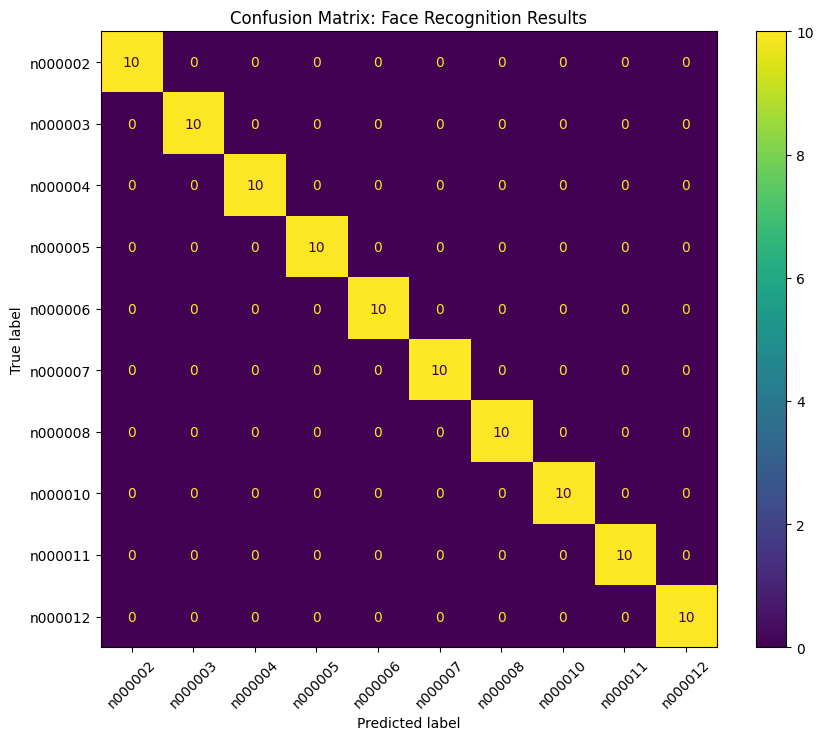

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

# ==========================================
# 1. Get predictions for all test images
# ==========================================
y_pred = clf.predict(X_test)
y_true = y_test

# ==========================================
# 2. Create performance table
# ==========================================
report = classification_report(
    y_true,
    y_pred,
    target_names=train_data.classes,
    output_dict=True
)

performance_table = pd.DataFrame(report).transpose()

print("Overall Accuracy:", accuracy_score(y_true, y_pred))
display(performance_table)

# ==========================================
# 3. Confusion matrix graph
# ==========================================
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Face Recognition Results")
plt.show()

In [ ]:
from facenet_pytorch import MTCNN
from PIL import Image
import torch
import numpy as np
from google.colab import files

mtcnn = MTCNN(image_size=160, margin=20, device=device)

def get_cropped_face_embedding(image_path):
    img = Image.open(image_path).convert("RGB")

    face = mtcnn(img)

    if face is None:
        raise ValueError(f"No face detected in {image_path}")

    face = face.unsqueeze(0).to(device)

    facenet.eval()
    with torch.no_grad():
        emb = facenet(face).cpu().numpy()[0]

    return emb

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def verify_two_faces(image_path_1, image_path_2, threshold=0.55):
    emb1 = get_cropped_face_embedding(image_path_1)
    emb2 = get_cropped_face_embedding(image_path_2)

    similarity = cosine_similarity(emb1, emb2)

    print("Similarity score:", similarity)

    if similarity >= threshold:
        print("Result: SAME PERSON")
    else:
        print("Result: DIFFERENT PERSON")

uploaded = files.upload()
uploaded_files = list(uploaded.keys())

image1 = uploaded_files[0]
image2 = uploaded_files[1]

verify_two_faces(image1, image2, threshold=0.65)

Saving IMG_2343.JPG to IMG_2343 (5).JPG
Saving IMG_2350-min-min.png to IMG_2350-min-min (8).png
Similarity score: 0.51262134
Result: DIFFERENT PERSON


In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Using file:", filename)

predict_image_with_threshold(filename)

Saving IMG_2343.JPG to IMG_2343 (2).JPG
Saving IMG_2350-min-min.png to IMG_2350-min-min (5).png
Using file: IMG_2343 (2).JPG
Prediction: UNKNOWN PERSON
Confidence: 0.40937021576152177


In [ ]:
!pip install pillow-heif -q

from PIL import Image
import pillow_heif

pillow_heif.register_heif_opener()

# ==========================================
# Face Verification: Compare 2 Images
# ==========================================
from PIL import Image
import torch
import numpy as np
from google.colab import files

def get_face_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    facenet.eval()
    with torch.no_grad():
        emb = facenet(img)

    return emb.cpu().numpy()[0]


def cosine_similarity(emb1, emb2):
    return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))


def verify_faces(image_path_1, image_path_2, threshold=0.75):
    emb1 = get_face_embedding(image_path_1)
    emb2 = get_face_embedding(image_path_2)

    similarity = cosine_similarity(emb1, emb2)

    print("Cosine similarity:", similarity)

    if similarity >= threshold:
        print("Result: SAME PERSON")
    else:
        print("Result: DIFFERENT PERSON")


# ==========================================
# Upload 2 images and compare them
# ==========================================
uploaded = files.upload()

uploaded_files = list(uploaded.keys())

if len(uploaded_files) < 2:
    print("Please upload 2 images.")
else:
    image1 = uploaded_files[0]
    image2 = uploaded_files[1]

    print("Image 1:", image1)
    print("Image 2:", image2)

    verify_faces(image1, image2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 11.5 MB/s eta 0:00:00


Saving IMG_2343.JPG to IMG_2343 (1).JPG
Saving IMG_2350-min-min.png to IMG_2350-min-min (4).png
Image 1: IMG_2343 (1).JPG
Image 2: IMG_2350-min-min (4).png
Cosine similarity: 0.4055663
Result: DIFFERENT PERSON
